# Équilibrage des classes

## Objectif

Le jeu de données **CICIDS2017** présente un fort déséquilibre entre les différentes classes. La classe **BENIGN** est largement majoritaire, tandis que plusieurs types d'attaques ne disposent que d'un nombre très limité d'observations.

Ce déséquilibre peut entraîner un biais lors de l'apprentissage des modèles de Machine Learning, qui auront tendance à privilégier la classe majoritaire au détriment des classes minoritaires. Afin d'améliorer la capacité des modèles à détecter les différentes catégories d'attaques, une étape d'équilibrage des classes est réalisée.

Étant donné la taille importante du jeu de données (plus de deux millions d'observations), un sur-échantillonnage complet aurait entraîné une augmentation excessive du volume des données. Une approche hybride est donc adoptée :

- réduction de la classe majoritaire à l'aide de **RandomUnderSampler** ;
- augmentation des classes les moins représentées à l'aide de **RandomOverSampler**.

Cette stratégie permet d'obtenir un ensemble d'entraînement plus équilibré tout en conservant une taille compatible avec les ressources matérielles disponibles.

In [22]:
import pandas as pd

X_train = pd.read_csv("./data/processed/X_train_scaled.csv")
y_train = pd.read_csv("./data/processed/y_train.csv").squeeze()

print("Dimensions :")
print(X_train.shape)
print(y_train.shape)

Dimensions :
(2017889, 47)
(2017889,)


## Répartition initiale des classes

Avant d'appliquer une méthode d'équilibrage, il est nécessaire d'examiner la distribution des classes présentes dans l'ensemble d'entraînement afin d'évaluer l'importance du déséquilibre.

In [23]:
print(y_train.value_counts().sort_index())

Label_encoded
0     1677187
1        1562
2      102413
3        8229
4      138279
5        4182
6        4308
7        4746
8           9
9          29
10      72655
11       2575
12       1176
13         17
14        522
Name: count, dtype: int64


## Réduction de la classe majoritaire

Dans un premier temps, un **RandomUnderSampler** est appliqué afin de réduire le nombre d'observations de la classe majoritaire (**BENIGN**).

Cette opération permet de diminuer le volume global des données et de limiter les coûts de calcul tout en conservant l'intégralité des observations appartenant aux autres classes.

In [24]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(
    sampling_strategy={0:300000},
    random_state=42
)

X_under, y_under = rus.fit_resample(
    X_train,
    y_train
)

## Vérification après le sous-échantillonnage

Les dimensions du nouvel ensemble d'entraînement ainsi que la nouvelle distribution des classes sont vérifiées afin de confirmer que seule la classe majoritaire a été réduite.

In [25]:
print(X_under.shape)

print(y_under.value_counts().sort_index())

(640702, 47)
Label_encoded
0     300000
1       1562
2     102413
3       8229
4     138279
5       4182
6       4308
7       4746
8          9
9         29
10     72655
11      2575
12      1176
13        17
14       522
Name: count, dtype: int64


## Sur-échantillonnage des classes minoritaires

Après la réduction de la classe majoritaire, un **RandomOverSampler** est appliqué aux classes les moins représentées.

Contrairement à un sur-échantillonnage complet, seules les classes présentant un faible nombre d'observations sont augmentées jusqu'à un seuil fixé. Cette approche permet d'améliorer la représentation des classes minoritaires sans générer un volume excessif de données.

In [26]:
from imblearn.over_sampling import RandomOverSampler

sampling = {
    1:10000,
    3:10000,
    5:10000,
    6:10000,
    7:10000,
    8:5000,
    9:5000,
    11:10000,
    12:10000,
    13:5000,
    14:5000
}

ros = RandomOverSampler(
    sampling_strategy=sampling,
    random_state=42
)

X_balanced, y_balanced = ros.fit_resample(
    X_under,
    y_under
)

## Vérification après le sur-échantillonnage

Les dimensions des données sont à nouveau vérifiées afin d'évaluer l'impact du sur-échantillonnage sur le volume du jeu de données.

In [27]:
print(X_balanced.shape)

print(y_balanced.shape)

(703347, 47)
(703347,)


## Distribution finale des classes

La répartition des classes après le processus d'équilibrage est analysée afin de vérifier que les classes minoritaires disposent désormais d'un nombre d'observations plus important.

In [28]:
print(y_balanced.value_counts().sort_index())

Label_encoded
0     300000
1      10000
2     102413
3      10000
4     138279
5      10000
6      10000
7      10000
8       5000
9       5000
10     72655
11     10000
12     10000
13      5000
14      5000
Name: count, dtype: int64


## Visualisation de la distribution des classes

Une représentation graphique permet d'observer la nouvelle distribution des classes après l'application du sous-échantillonnage et du sur-échantillonnage.

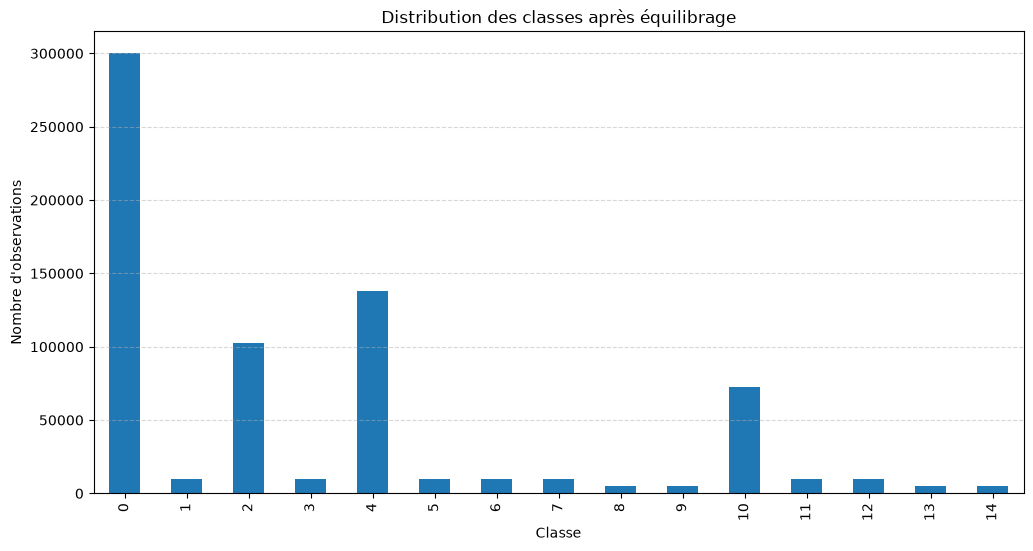

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

y_balanced.value_counts().sort_index().plot(kind="bar")

plt.title("Distribution des classes après équilibrage")

plt.xlabel("Classe")

plt.ylabel("Nombre d'observations")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

## Sauvegarde des données équilibrées

Les ensembles d'entraînement rééquilibrés sont enregistrés afin d'être directement utilisés lors de la phase d'entraînement des modèles de Machine Learning.

In [30]:
X_balanced.to_csv(
    "./data/processed/X_train_balanced.csv",
    index=False
)

pd.DataFrame(y_balanced).to_csv(
    "./data/processed/y_train_balanced.csv",
    index=False
)

print("Les données ont été sauvegardées avec succès.")

Les données ont été sauvegardées avec succès.


## Conclusion

L'application successive d'un **RandomUnderSampler** puis d'un **RandomOverSampler** a permis de réduire le déséquilibre entre les différentes classes du jeu de données tout en conservant un volume de données compatible avec les ressources disponibles.

Les données obtenues constituent le nouvel ensemble d'entraînement qui sera utilisé dans la phase suivante pour l'apprentissage et l'évaluation des modèles de Machine Learning.